## PREPARING DATA

In [1]:
#the import packages
import requests
import pandas as pd
from pandas import json_normalize
import requests
import os
from pathlib import Path
from datetime import datetime, timezone,timedelta,time
from scipy import stats
import json
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
from matplotlib.ticker import MultipleLocator


In [3]:
pd.set_option("display.max_columns", None)

In [4]:
def loadDataFromFile(file_name):
    script_dir = Path().resolve().parent
    print(script_dir)
    data_folder = script_dir /'data'
    print(data_folder)
    data_folder.mkdir(exist_ok=True)
    
    file_path = data_folder / (file_name + ".json")
    
    if file_path.exists():
        df = pd.read_json(file_path)
        print(f"Loaded {len(df)} records from {file_path}")
        return df
    else:
        print(f"File {file_path} does not exist.")
        return None    

In [5]:
userInputDataRaw = loadDataFromFile("UserPrevious experiments-preprocessed")
timeSeriesData_BIGraw = loadDataFromFile("Data:Previous experiments-preprocessed")

C:\Users\Andreas\Documents\PlatformIO\Projects\Diploma Project\dataAnalysis and machine learning
C:\Users\Andreas\Documents\PlatformIO\Projects\Diploma Project\dataAnalysis and machine learning\data
Loaded 257 records from C:\Users\Andreas\Documents\PlatformIO\Projects\Diploma Project\dataAnalysis and machine learning\data\UserPrevious experiments-preprocessed.json
C:\Users\Andreas\Documents\PlatformIO\Projects\Diploma Project\dataAnalysis and machine learning
C:\Users\Andreas\Documents\PlatformIO\Projects\Diploma Project\dataAnalysis and machine learning\data
Loaded 229277 records from C:\Users\Andreas\Documents\PlatformIO\Projects\Diploma Project\dataAnalysis and machine learning\data\Data:Previous experiments-preprocessed.json


In [6]:
timeSeriesData_BIGraw = timeSeriesData_BIGraw.set_index("seconds",drop=False)

In [7]:
a = userInputDataRaw.index
b = timeSeriesData_BIGraw["keys"].unique()
diff_all = list(set(a).symmetric_difference(set(b)))
print(diff_all)  
userInputDataRaw.index = timeSeriesData_BIGraw["keys"].unique()
print(userInputDataRaw.index)

[6, 49, 257, 258]
Index([  0,   1,   2,   3,   4,   5,   7,   8,   9,  10,
       ...
       249, 250, 251, 252, 253, 254, 255, 256, 257, 258],
      dtype='int64', length=257)


In [8]:
# Convert back to timedelta
timeSeriesData_BIGraw['timestamp'] = pd.to_timedelta(timeSeriesData_BIGraw['timestamp'], unit='ms')

# Convert back to datetime

timeSeriesData_BIGraw ["datetime_timestamp"]= timeSeriesData_BIGraw['datetime_timestamp'].transform(
    lambda x: pd.to_datetime(x, unit='ms')
)


columns_datetime= [
       'date of experiment', 'actual timestamp StartingExperiment',
       'actual timestamp EndingExperiment']
columns_timedelta = ['time taken total','time taken before insertion',
       'timestamp InsertingSource timedelta',
       'time taken after insertion']
# Ensure target columns are of object type before assignment
userInputDataRaw[columns_datetime] = userInputDataRaw[columns_datetime].astype('object')
userInputDataRaw[columns_timedelta] = userInputDataRaw[columns_timedelta].astype('object')

userInputDataRaw.loc[:,columns_datetime] = userInputDataRaw.loc[:,columns_datetime].apply(lambda x:pd.to_datetime(x, unit='ms'))
userInputDataRaw.loc[:,columns_timedelta] = userInputDataRaw.loc[:,columns_timedelta].apply(lambda x:pd.to_timedelta(x, unit='ms'))

In [9]:
timeSeriesData_BIG = timeSeriesData_BIGraw.copy()
userInputData = userInputDataRaw.copy()

In [10]:
userInputData

,experimentState,are-doors-opened,are-people-inside,are-windows-opened,front-wall,item-used,notes,room,side-right-wall,back-wall,side-left-wall,are-fans-on,no-source-located,timestamp InsertingSource,timestamp StartingExperiment,timestamp EndingExperiment,date of experiment,actual timestamp StartingExperiment,actual timestamp EndingExperiment,time taken total,timestamp InsertingSource timedelta,timestamp InsertingSource seconds,time taken after insertion,time taken before insertion,time taken before insertion (seconds),time taken after insertion (seconds),time taken total (seconds),time taken total (seconds)-capped,time taken before insertion (seconds)-capped,time taken after insertion (seconds)-capped,Id=1:BME680:breathVocEquivalent MAX value VOC rolling average,Id=1:BME680:breathVocEquivalent index of MAX value VOC rolling average,Id=2:BME680:breathVocEquivalent MAX value VOC rolling average,Id=2:BME680:breathVocEquivalent index of MAX value VOC rolling average,Id=0:BME680:breathVocEquivalent MAX value VOC rolling average,Id=0:BME680:breathVocEquivalent index of MAX value VOC rolling average,sensor with MAX value experiment,sensor with second MAX value experiment,Id=1:BME680:breathVocEquivalent quantile 90.0% VOC rolling average,Id=1:BME680:breathVocEquivalent quantile 99.0% VOC rolling average,Id=2:BME680:breathVocEquivalent quantile 90.0% VOC rolling average,Id=2:BME680:breathVocEquivalent quantile 99.0% VOC rolling average,Id=0:BME680:breathVocEquivalent quantile 90.0% VOC rolling average,Id=0:BME680:breathVocEquivalent quantile 99.0% VOC rolling average,whole experiment quantile 90.0% VOC rolling average,whole experiment quantile 99.0% VOC rolling average,Id=1:BME680:breathVocEquivalent VOC mean calm period,Id=1:BME680:breathVocEquivalent VOC gradient mean calm period,Id=2:BME680:breathVocEquivalent VOC mean calm period,Id=2:BME680:breathVocEquivalent VOC gradient mean calm period,Id=0:BME680:breathVocEquivalent VOC mean calm period,Id=0:BME680:breathVocEquivalent VOC gradient mean calm period,x axis,y axis,x-y axis,position of Id=0:BME680:breathVocEquivalent-x axis,position of Id=0:BME680:breathVocEquivalent-y axis,position of Id=1:BME680:breathVocEquivalent-x axis,position of Id=1:BME680:breathVocEquivalent-y axis,position of Id=2:BME680:breathVocEquivalent-x axis,position of Id=2:BME680:breathVocEquivalent-y axis,position of Id=0:BME680:breathVocEquivalent x-y axis,position of Id=1:BME680:breathVocEquivalent x-y axis,position of Id=2:BME680:breathVocEquivalent x-y axis,Euclidian distance to Id=0:BME680:breathVocEquivalent,Euclidian distance to Id=1:BME680:breathVocEquivalent,Euclidian distance to Id=2:BME680:breathVocEquivalent
0,InsertingSourcePollutant,on,None,None,1.0,Φαρμακευτικό αλκοόλ 95%,,Κρεβατοκάμαρα id:1 Μ0.95 Α0.85 id:2 Μ0.95 Α1.55,NaN,NaN,1.0,None,None,2025-07-01 16:09:41,2025-07-01 15:27:16,2025-07-01 16:14:44,2025-07-01 00:00:00,2025-07-01 15:27:19,2025-07-01 16:14:42,0 days 00:47:23,0 days 00:42:23,2543,0 days 00:05:00,0 days 00:42:23,2543,300,2843,270,-30,299,4.3501,299.0,8.1928,243,NaN,NaN,Id=2:BME680:breathVocEquivalent MAX value VOC ...,Id=1:BME680:breathVocEquivalent MAX value VOC ...,4.10260,4.342653,8.13641,8.191397,NaN,NaN,8.03289,8.186653,1.338333,0.000302,5.003467,0.001410,NaN,NaN,-2.25,3.0,"[-2.25, 3.0]",NaN,NaN,2.4,3.05,1.70,3.05,"[None, None]","[2.4, 3.05]","[1.7000000000000002, 3.05]",NaN,4.65,3.95
1,InsertingSourcePollutant,on,None,None,1.0,Φαρμακευτικό αλκοόλ 95%,,Κρεβατοκάμαρα id:1 Μ0.95 Α0.85 id:2 Μ0.95 Α1.55,NaN,NaN,1.0,None,None,2025-07-02 15:59:29,2025-07-02 15:42:50,2025-07-02 16:04:52,2025-07-02 00:00:00,2025-07-02 15:42:50,2025-07-02 16:04:50,0 days 00:22:00,0 days 00:16:40,1000,0 days 00:05:20,0 days 00:16:40,1000,320,1320,270,-30,299,1.1333,201.0,0.3304,80,NaN,NaN,Id=1:BME680:breathVocEquivalent MAX value VOC ...,Id=2:BME680:breathVocEquivalent MAX value VOC ...,0.96260,1.130830,0.30518,0.330042,NaN,NaN,0.74384,1.123456,0.050000,-0.000188,0.149700,0.002748,NaN,NaN,-2.25,3.0,"[-

In [11]:
userInputData["room"].unique()

array(['Κρεβατοκάμαρα id:1 Μ0.95 Α0.85 id:2 Μ0.95 Α1.55',
       'Κρεβατοκάμαρα id:1 Π0.6 Α1.2 id:2 Μ0.8 Α1.1',
       'Κρεβατοκάμαρα-Όλοι οι αισθητήρες μαζί Μ:0.80 , Α:0.90',
       'Κρεβατοκάμαρα id:0 Μ:0.5 Α:1.4 ,id:1 Π:1.7 Δ:0.5  ,id:2 Π:0.4 Α:1.0',
       'Κρεβατοκάμαρα Όλοι οι αισθητήρες μαζί Π:1.80 , Δ:2.00'],
      dtype=object)

In [12]:
#keep the data from the last set experiments made that have the 3 sensors in a triangle shape,they have 16 particular points in the space d
room_mask = userInputData["room"].isin(['Κρεβατοκάμαρα id:0 Μ:0.5 Α:1.4 ,id:1 Π:1.7 Δ:0.5  ,id:2 Π:0.4 Α:1.0'])
open_door_mask = userInputData["are-doors-opened"] != "on"

mask = room_mask  & open_door_mask
userInputData = userInputData.loc[mask]
#grab all the data that are contained in those experiments
timeSeriesData_BIG = timeSeriesData_BIG.loc[timeSeriesData_BIG["keys"].isin(userInputData.index)]

In [13]:
userInputData

,experimentState,are-doors-opened,are-people-inside,are-windows-opened,front-wall,item-used,notes,room,side-right-wall,back-wall,side-left-wall,are-fans-on,no-source-located,timestamp InsertingSource,timestamp StartingExperiment,timestamp EndingExperiment,date of experiment,actual timestamp StartingExperiment,actual timestamp EndingExperiment,time taken total,timestamp InsertingSource timedelta,timestamp InsertingSource seconds,time taken after insertion,time taken before insertion,time taken before insertion (seconds),time taken after insertion (seconds),time taken total (seconds),time taken total (seconds)-capped,time taken before insertion (seconds)-capped,time taken after insertion (seconds)-capped,Id=1:BME680:breathVocEquivalent MAX value VOC rolling average,Id=1:BME680:breathVocEquivalent index of MAX value VOC rolling average,Id=2:BME680:breathVocEquivalent MAX value VOC rolling average,Id=2:BME680:breathVocEquivalent index of MAX value VOC rolling average,Id=0:BME680:breathVocEquivalent MAX value VOC rolling average,Id=0:BME680:breathVocEquivalent index of MAX value VOC rolling average,sensor with MAX value experiment,sensor with second MAX value experiment,Id=1:BME680:breathVocEquivalent quantile 90.0% VOC rolling average,Id=1:BME680:breathVocEquivalent quantile 99.0% VOC rolling average,Id=2:BME680:breathVocEquivalent quantile 90.0% VOC rolling average,Id=2:BME680:breathVocEquivalent quantile 99.0% VOC rolling average,Id=0:BME680:breathVocEquivalent quantile 90.0% VOC rolling average,Id=0:BME680:breathVocEquivalent quantile 99.0% VOC rolling average,whole experiment quantile 90.0% VOC rolling average,whole experiment quantile 99.0% VOC rolling average,Id=1:BME680:breathVocEquivalent VOC mean calm period,Id=1:BME680:breathVocEquivalent VOC gradient mean calm period,Id=2:BME680:breathVocEquivalent VOC mean calm period,Id=2:BME680:breathVocEquivalent VOC gradient mean calm period,Id=0:BME680:breathVocEquivalent VOC mean calm period,Id=0:BME680:breathVocEquivalent VOC gradient mean calm period,x axis,y axis,x-y axis,position of Id=0:BME680:breathVocEquivalent-x axis,position of Id=0:BME680:breathVocEquivalent-y axis,position of Id=1:BME680:breathVocEquivalent-x axis,position of Id=1:BME680:breathVocEquivalent-y axis,position of Id=2:BME680:breathVocEquivalent-x axis,position of Id=2:BME680:breathVocEquivalent-y axis,position of Id=0:BME680:breathVocEquivalent x-y axis,position of Id=1:BME680:breathVocEquivalent x-y axis,position of Id=2:BME680:breathVocEquivalent x-y axis,Euclidian distance to Id=0:BME680:breathVocEquivalent,Euclidian distance to Id=1:BME680:breathVocEquivalent,Euclidian distance to Id=2:BME680:breathVocEquivalent
145,NoSourcePollutantInserted,None,None,None,NaN,Φαρμακευτικό αλκοόλ 95%,,"Κρεβατοκάμαρα id:0 Μ:0.5 Α:1.4 ,id:1 Π:1.7 Δ:0...",NaN,NaN,NaN,None,on,2025-10-13 18:12:35,2025-10-13 18:12:23,2025-10-13 18:19:58,2025-10-13 00:00:00,2025-10-13 18:12:24,2025-10-13 18:19:56,0 days 00:07:32,0 days 00:00:12,12,0 days 00:07:20,0 days 00:00:12,12,440,452,288,-12,299,0.2190,299.0,0.2297,255,0.1309,299.0,Id=2:BME680:breathVocEquivalent MAX value VOC ...,Id=1:BME680:breathVocEquivalent MAX value VOC ...,0.18758,0.210014,0.22307,0.229500,0.10019,0.129212,0.20155,0.229130,0.148821,0.000534,0.126362,0.000542,0.063558,0.000061,NaN,NaN,"[None, None]",-1.85,3.5,-0.5,1.7,-2.25,0.4,"[-1.85, 3.5]","[-0.5, 1.7000000000000002]","[-2.25, 0.4]",NaN,NaN,NaN
146,InsertingSourcePollutant,None,None,None,1.5,Φαρμακευτικό αλκοόλ 95%,,"Κρεβατοκάμαρα id:0 Μ:0.5 Α:1.4 ,id:1 Π:1.7 Δ:0...",NaN,NaN,0.3,None,None,2025-10-13 18:26:12,2025-10-13 18:24:06,2025-10-13 18:57:52,2025-10-13 00:00:00,2025-10-13 18:24:08,2025-10-13 18:57:50,0 days 00:33:42,0 days 00:02:05,125,0 days 00:31:37,0 days 00:02:05,125,1897,2022,270,-30,299,0.3738,251.0,0.3577,294,0.2026,224.0,Id=1:BME680:breathVocEquivalent MAX value VOC ...,Id=2:BME680:breathVocEquivalent MAX value VOC ...,0.34415,0.373413,0.33478,0.357013,0.18951,0.202442,0.32881,0.370132,0.059467,0.

In [14]:
timeSeriesData_BIG

,keys,sensors,VOC,after_insertion,original_value,datetime_timestamp,timestamp,seconds,seconds passed from insertionSource,VOC original,VOC rolling average,original seconds,VOC-capped,VOC rolling average-capped,VOC gradient,VOC rolling average gradient,VOC rolling average standard scaler whole experiment,VOC rolling average-capped standard scaler whole experiment
seconds,,,,,,,,,,,,,,,,,,
-12,145,Id=0:BME680:breathVocEquivalent,0.119,False,False,2025-10-13 18:12:24,0 days 00:00:00,-12,-12,0.659488,0.1113,0,0.119,0.1113,-0.00160,-0.00160,-0.025275,-0.025275
-12,145,Id=1:BME680:breathVocEquivalent,0.000,False,False,2025-10-13 18:12:24,0 days 00:00:00,-12,-12,0.526446,0.0559,0,0.000,0.0559,0.00390,0.00390,-0.866511,-0.866511
-12,145,Id=2:BME680:breathVocEquivalent,0.045,False,True,2025-10-13 18:12:24,0 days 00:00:00,-12,-12,0.520286,0.0356,0,0.045,0.0356,0.00010,0.00010,-1.174762,-1.174762
-11,145,Id=0:BME680:breathVocEquivalent,0.118,False,False,2025-10-13 18:12:25,0 days 00:00:01,-11,-11,0.658610,0.1097,1,0.118,0.1097,-0.00165,-0.00165,-0.049571,-0.049571
-11,145,Id=1:BME680:breathVocEquivalent,0.006,False,False,2025-10-13 18:12:25,0 days 00:00:01,-11,-11,0.532204,0.0598,1,0.006,0.0598,0.00375,0.00375,-0.807290,-0.807290
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,258,Id=1:BME680:breathVocEquivalent,1.421,True,True,2025-10-24 21:59:04,0 days 00:06:46,298,298,2.948842,1.4032,406,1.421,1.4032,-0.00500,-0.00500,0.089182,0.089182
298,258,Id=2:BME680:breathVocEquivalent,3.343,True,False,2025-10-24 21:59:04,0 days 00:06:46,298,298,5.567955,3.3352,406,3.343,3.3352,-0.00835,-0.00835,2.251684,2.251684
299,258,Id=0:BME680:breathVocEquivalent,2.143,True,False,2025-10-24 21:59:05,0 days 00:06:47,299,299,3.110278,2.1139,407,2.143,2.1139,0.01260,0.01260,0.884674,0.884674


In [15]:
column_to_transform = "x-y axis"
userInputData.loc[:,column_to_transform] = userInputData.loc[:,column_to_transform].apply(tuple)

In [16]:
userInputData["x-y axis"].unique()

array([(None, None), (-2.95, 2.5), (-2.95, 3.5), (-0.5, 3.5), (-0.5, 2.5),
       (-0.5, 1.5), (-0.5, 0.5), (-1.5, 0.5), (-1.5, 1.5), (-1.5, 2.5),
       (-1.5, 3.5), (-2.5, 3.5), (-2.5, 2.5), (-2.5, 1.5), (-2.5, 0.5),
       (-2.95, 0.5), (-2.95, 1.5)], dtype=object)

In [17]:
#from the experiments with door open, drop the positions which doesn't fit to the 16 source position we are going to check the model
#also drop the experiments with the None values
axis_list = [(None, None), (-2.15, 2.0), (-1.35, 2.0), (-1.35, 1.5),
       (-1.35, 1.0), (-1.85, 1.0), (-1.85, 1.5)]
axis_mask = ~userInputData["x-y axis"].isin(axis_list)

mask = axis_mask 
userInputData = userInputData.loc[mask]
#grab all the data that are contained in those experiments
timeSeriesData_BIG = timeSeriesData_BIG.loc[timeSeriesData_BIG["keys"].isin(userInputData.index)]

In [18]:
userInputData

,experimentState,are-doors-opened,are-people-inside,are-windows-opened,front-wall,item-used,notes,room,side-right-wall,back-wall,side-left-wall,are-fans-on,no-source-located,timestamp InsertingSource,timestamp StartingExperiment,timestamp EndingExperiment,date of experiment,actual timestamp StartingExperiment,actual timestamp EndingExperiment,time taken total,timestamp InsertingSource timedelta,timestamp InsertingSource seconds,time taken after insertion,time taken before insertion,time taken before insertion (seconds),time taken after insertion (seconds),time taken total (seconds),time taken total (seconds)-capped,time taken before insertion (seconds)-capped,time taken after insertion (seconds)-capped,Id=1:BME680:breathVocEquivalent MAX value VOC rolling average,Id=1:BME680:breathVocEquivalent index of MAX value VOC rolling average,Id=2:BME680:breathVocEquivalent MAX value VOC rolling average,Id=2:BME680:breathVocEquivalent index of MAX value VOC rolling average,Id=0:BME680:breathVocEquivalent MAX value VOC rolling average,Id=0:BME680:breathVocEquivalent index of MAX value VOC rolling average,sensor with MAX value experiment,sensor with second MAX value experiment,Id=1:BME680:breathVocEquivalent quantile 90.0% VOC rolling average,Id=1:BME680:breathVocEquivalent quantile 99.0% VOC rolling average,Id=2:BME680:breathVocEquivalent quantile 90.0% VOC rolling average,Id=2:BME680:breathVocEquivalent quantile 99.0% VOC rolling average,Id=0:BME680:breathVocEquivalent quantile 90.0% VOC rolling average,Id=0:BME680:breathVocEquivalent quantile 99.0% VOC rolling average,whole experiment quantile 90.0% VOC rolling average,whole experiment quantile 99.0% VOC rolling average,Id=1:BME680:breathVocEquivalent VOC mean calm period,Id=1:BME680:breathVocEquivalent VOC gradient mean calm period,Id=2:BME680:breathVocEquivalent VOC mean calm period,Id=2:BME680:breathVocEquivalent VOC gradient mean calm period,Id=0:BME680:breathVocEquivalent VOC mean calm period,Id=0:BME680:breathVocEquivalent VOC gradient mean calm period,x axis,y axis,x-y axis,position of Id=0:BME680:breathVocEquivalent-x axis,position of Id=0:BME680:breathVocEquivalent-y axis,position of Id=1:BME680:breathVocEquivalent-x axis,position of Id=1:BME680:breathVocEquivalent-y axis,position of Id=2:BME680:breathVocEquivalent-x axis,position of Id=2:BME680:breathVocEquivalent-y axis,position of Id=0:BME680:breathVocEquivalent x-y axis,position of Id=1:BME680:breathVocEquivalent x-y axis,position of Id=2:BME680:breathVocEquivalent x-y axis,Euclidian distance to Id=0:BME680:breathVocEquivalent,Euclidian distance to Id=1:BME680:breathVocEquivalent,Euclidian distance to Id=2:BME680:breathVocEquivalent
146,InsertingSourcePollutant,None,None,None,1.5,Φαρμακευτικό αλκοόλ 95%,,"Κρεβατοκάμαρα id:0 Μ:0.5 Α:1.4 ,id:1 Π:1.7 Δ:0...",NaN,NaN,0.3,None,None,2025-10-13 18:26:12,2025-10-13 18:24:06,2025-10-13 18:57:52,2025-10-13 00:00:00,2025-10-13 18:24:08,2025-10-13 18:57:50,0 days 00:33:42,0 days 00:02:05,125,0 days 00:31:37,0 days 00:02:05,125,1897,2022,270,-30,299,0.3738,251.0,0.3577,294,0.2026,224.0,Id=1:BME680:breathVocEquivalent MAX value VOC ...,Id=2:BME680:breathVocEquivalent MAX value VOC ...,0.34415,0.373413,0.33478,0.357013,0.18951,0.202442,0.32881,0.370132,0.059467,0.001485,0.068867,0.001000,0.087333,0.000453,-2.95,2.5,"(-2.95, 2.5)",-1.85,3.5,-0.5,1.7,-2.25,0.4,"[-1.85, 3.5]","[-0.5, 1.7000000000000002]","[-2.25, 0.4]",1.49,2.58,2.21
147,InsertingSourcePollutant,None,None,None,0.5,Φαρμακευτικό αλκοόλ 95%,,"Κρεβατοκάμαρα id:0 Μ:0.5 Α:1.4 ,id:1 Π:1.7 Δ:0...",NaN,NaN,0.3,None,None,2025-10-13 19:13:50,2025-10-13 19:11:41,2025-10-13 19:20:00,2025-10-13 00:00:00,2025-10-13 19:11:42,2025-10-13 19:19:59,0 days 00:08:17,0 days 00:02:09,129,0 days 00:06:08,0 days 00:02:09,129,368,497,270,-30,299,0.6778,229.0,0.9853,227,0.6536,299.0,Id=2:BME680:breathVocEquivalent MAX value VOC ...,Id=1:BME680:breathVocEquivalent MAX value VOC ...,0.63975,0.676668,0.95069,0.984642,0.42454,0.643353,0.83994,0.982088,0.1

In [19]:
timeSeriesData_BIG

,keys,sensors,VOC,after_insertion,original_value,datetime_timestamp,timestamp,seconds,seconds passed from insertionSource,VOC original,VOC rolling average,original seconds,VOC-capped,VOC rolling average-capped,VOC gradient,VOC rolling average gradient,VOC rolling average standard scaler whole experiment,VOC rolling average-capped standard scaler whole experiment
seconds,,,,,,,,,,,,,,,,,,
-30,146,Id=2:BME680:breathVocEquivalent,0.046,False,False,2025-10-13 18:25:43,0 days 00:01:35,-30,-30,0.582328,0.0475,95,0.046,0.0475,0.00110,0.00110,-0.935147,-0.935147
-30,146,Id=0:BME680:breathVocEquivalent,0.071,False,False,2025-10-13 18:25:43,0 days 00:01:35,-30,-30,0.562739,0.0716,95,0.071,0.0716,0.00120,0.00120,-0.710947,-0.710947
-30,146,Id=1:BME680:breathVocEquivalent,0.046,False,False,2025-10-13 18:25:43,0 days 00:01:35,-30,-30,0.760840,0.0489,95,0.046,0.0489,0.00010,0.00010,-0.922123,-0.922123
-29,146,Id=2:BME680:breathVocEquivalent,0.049,False,False,2025-10-13 18:25:44,0 days 00:01:36,-29,-29,0.584810,0.0486,96,0.049,0.0486,0.00110,0.00110,-0.924914,-0.924914
-29,146,Id=0:BME680:breathVocEquivalent,0.073,False,True,2025-10-13 18:25:44,0 days 00:01:36,-29,-29,0.564405,0.0728,96,0.073,0.0728,0.00125,0.00125,-0.699783,-0.699783
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,258,Id=1:BME680:breathVocEquivalent,1.421,True,True,2025-10-24 21:59:04,0 days 00:06:46,298,298,2.948842,1.4032,406,1.421,1.4032,-0.00500,-0.00500,0.089182,0.089182
298,258,Id=2:BME680:breathVocEquivalent,3.343,True,False,2025-10-24 21:59:04,0 days 00:06:46,298,298,5.567955,3.3352,406,3.343,3.3352,-0.00835,-0.00835,2.251684,2.251684
299,258,Id=0:BME680:breathVocEquivalent,2.143,True,False,2025-10-24 21:59:05,0 days 00:06:47,299,299,3.110278,2.1139,407,2.143,2.1139,0.01260,0.01260,0.884674,0.884674


In [20]:
userInputData.loc[userInputData["are-doors-opened"]=="on"].shape

(0, 67)

In [21]:
userInputData.loc[userInputData["are-doors-opened"]!="on"].shape

(98, 67)

In [22]:
max_before= -30
max_after = 299

column_to_check = "time taken before insertion (seconds)-capped"
mask = userInputData[column_to_check] >max_before
print(f"{column_to_check} < {max_before}:\n {userInputData.loc[mask,column_to_check]}")

column_to_check = "time taken after insertion (seconds)-capped"
mask = userInputData[column_to_check] < max_after
print(f"{column_to_check} < {max_after}:\n {userInputData.loc[mask,column_to_check]}")
print(f"userInputData rows {userInputData.shape[0]}")

time taken before insertion (seconds)-capped < -30:
 Series([], Name: time taken before insertion (seconds)-capped, dtype: int64)
time taken after insertion (seconds)-capped < 299:
 Series([], Name: time taken after insertion (seconds)-capped, dtype: int64)
userInputData rows 98


In [23]:
max_before= -30
max_after = 299

mask_before = (userInputData["time taken before insertion (seconds)-capped"] == max_before)
max_after = (userInputData["time taken after insertion (seconds)-capped"] == max_after)
mask = mask_before & max_after

userInputData = userInputData.loc[mask,:].copy()
print(f"userInputData rows {userInputData.shape[0]}")
timeSeriesData_BIG = timeSeriesData_BIG.loc[timeSeriesData_BIG["keys"].isin(userInputData.index)]

userInputData rows 98


## PRINT DATA PER SENSOR

### Split back into dict
dict_of_timeseries = {k: v.drop(columns="keys").reset_index(drop=True) 
             for k, v in timeSeriesData_BIG.groupby("keys")}
for index,data in dict_of_timeseries.items():
    dict_of_timeseries[index] = dict_of_timeseries[index].set_index("seconds",drop=False)

In [24]:
def plot_position(userInputData,sample_row_of_the_group):
    plt.figure(figsize=(6, 6))  
    position_of_sensors = userInputData.iloc[-1]
    all_positions = userInputData.loc[:, ["x axis", "y axis"]]
    # Extra points
    extra_positions = np.array([
        [position_of_sensors["position of Id=0:BME680:breathVocEquivalent-x axis"], position_of_sensors["position of Id=0:BME680:breathVocEquivalent-y axis"]],
    
        [position_of_sensors["position of Id=1:BME680:breathVocEquivalent-x axis"], position_of_sensors["position of Id=1:BME680:breathVocEquivalent-y axis"]],
        [position_of_sensors["position of Id=2:BME680:breathVocEquivalent-x axis"], position_of_sensors["position of Id=2:BME680:breathVocEquivalent-y axis"]]
    ])
    extra_ids = ["id0","id1", "id2"]
    
    
    room_length = 4.0
    room_width = 3.25
    
    
    # Create scatterplot of the sources of all the particular setup
    #sns.scatterplot(x=positions[:,0], y=positions[:,1])
    sns.scatterplot(data=all_positions, x="x axis", y="y axis", color='blue', s=100, label='User Input Data')
    
    
    
    # Add the positions of sensors
    sns.scatterplot(x=extra_positions[:,0], y=extra_positions[:,1], color='red', s=100)
    x_sensor_highlight = sample_row_of_the_group["x axis"]
    y_sensor_highlight = sample_row_of_the_group["y axis"]
    # Plot a hollow circle around it
    plt.scatter(x_sensor_highlight, y_sensor_highlight, s=500, facecolors='none', edgecolors='green', linewidths=2, label='Highlighted point')  
    # Draw lines and annotate distances
    distances_from_sensors = (
        sample_row_of_the_group["Euclidian distance to Id=0:BME680:breathVocEquivalent"],
        sample_row_of_the_group["Euclidian distance to Id=1:BME680:breathVocEquivalent"],
        sample_row_of_the_group["Euclidian distance to Id=2:BME680:breathVocEquivalent"]
    )
    
    for i, (x, y) in enumerate(extra_positions):
        plt.plot([x_sensor_highlight, x], [y_sensor_highlight, y], color='red', linewidth=0.7, alpha=0.7)
        
        if distances_from_sensors is not None:
            # Midpoint of the line for annotation
            mid_x = (x_sensor_highlight + x) / 2
            mid_y = (y_sensor_highlight + y) / 2
            plt.text(mid_x, mid_y, f"{distances_from_sensors[i]:.2f}", color='red', fontsize=8, ha='center', va='center',
                         bbox=dict(facecolor='white', edgecolor='none', alpha=0.6, pad=1))
    # Annotate extra points with their IDs
    for i, (x, y) in enumerate(extra_positions):
        plt.text(x, y, extra_ids[i], fontsize=12, ha='right', va='bottom', color='red')
    
    
    # Set axis limits
    plt.xlim(-room_width, 0)
    plt.ylim(0, room_length)
    
    # Add grid
    plt.grid(True, which="both", linestyle="--", linewidth=0.7, alpha=0.7)
    # Smaller legend
    plt.legend(fontsize=8, markerscale=0.8, labelspacing=0.4)

    plt.show()

In [25]:
def printDataBasedOnDate(column_to_print,userInputData,timeSeriesData_BIG,room_other_grouping,type_of_other_grouping):
    
    column_names_keys_color_values = {"Id=0:BME680:breathVocEquivalent":"blue","Id=1:BME680:breathVocEquivalent":"green","Id=2:BME680:breathVocEquivalent":"yellow"}
    
    for group_name,indexes_of_the_group in room_other_grouping.items(): 
        timeSeriesData_BIG_copy = timeSeriesData_BIG.copy() 

        if ("position"  in type_of_other_grouping):
            sample_row_of_the_group = userInputData.loc[indexes_of_the_group[0],:]
            
            plot_position(userInputData,sample_row_of_the_group)       
        print(f"group_name {group_name}")
        print(f"indexes_of_the_group {indexes_of_the_group}")
        data = timeSeriesData_BIG_copy.loc[timeSeriesData_BIG_copy["keys"].isin(indexes_of_the_group),:]  
      # Create relplot
        g = sns.relplot(
            data=data,
            x="seconds",
            y=column_to_print,
            hue="sensors",
            col="keys",        # separate subplot per key
            kind="line",
            col_wrap=3, 
                height=7,    # default = 5
            aspect=1, # width = height × aspect (so 6 × 1.5 = 9 inches wide per subplot
            palette=column_names_keys_color_values,  # <<< ensures the same colors across all subplots  
            linewidth=2,
           facet_kws={
            "sharex": False,
            "sharey": False       
    
        })
        

        # >>> ADD THIS PART <<<
        for ax in g.axes.flat:
            ax.xaxis.set_major_locator(MultipleLocator(30))
            ax.xaxis.set_minor_locator(MultipleLocator(10))
            ax.grid(True, which='both', linestyle=':', linewidth=0.5)
            
 
        
    # Get the horizontal and  vertical line position for this experiment
        for key_value, ax in g.axes_dict.items():
           
                #value to show the time that source is inserted
          
            userInputDataRow = userInputData.loc[key_value,:]
        #    x_position = f"side-right-wall {userInputDataRow['side-right-wall']},side-left-wall {userInputDataRow['side-left-wall']} \n"
        #    y_position = f"front-wall {userInputDataRow['front-wall']},back-wall {userInputDataRow['back-wall']} \n"
            
            euclidian_distances = (
                                  f"distance from Id0 sensor {userInputDataRow['Euclidian distance to Id=0:BME680:breathVocEquivalent']}\n",
                                  f"distance from Id1 sensor {userInputDataRow['Euclidian distance to Id=1:BME680:breathVocEquivalent']}\n",
                                  f"distance from Id2 sensor {userInputDataRow['Euclidian distance to Id=2:BME680:breathVocEquivalent']}\n",
            )
            subtitle=  (
                        f"At experiment with key {key_value}\n datetime:{userInputDataRow['actual timestamp StartingExperiment']}\n", 
                        f"experimentState:{userInputDataRow['experimentState']}\n",
                        f"x-axis: {userInputDataRow['x axis']} , y-axis: {userInputDataRow['y axis']}\n"
            )
            if ("distance"  in type_of_other_grouping):
               subtitle = subtitle + "\n"+euclidian_distances  
            ax.set_title(subtitle, fontsize=9)   
            g.fig.suptitle(f"Group: {group_name}", fontsize=16)
        
            g.fig.subplots_adjust(
                    top=0.75,   # space for overall title
                    wspace=0.2, # horizontal space between subplots
                    hspace=0.3 # vertical space between subplots
                   )

        plt.show()   
             

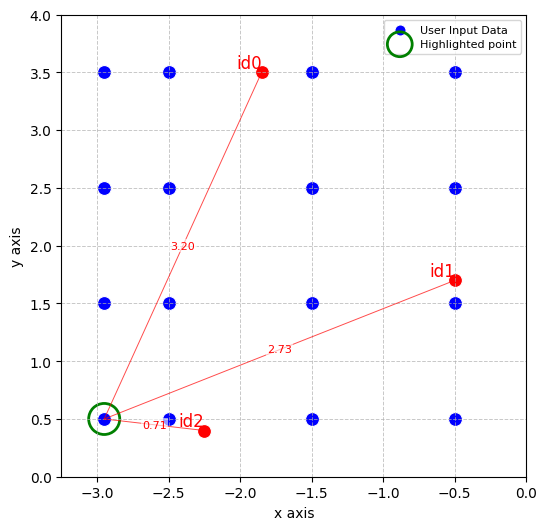

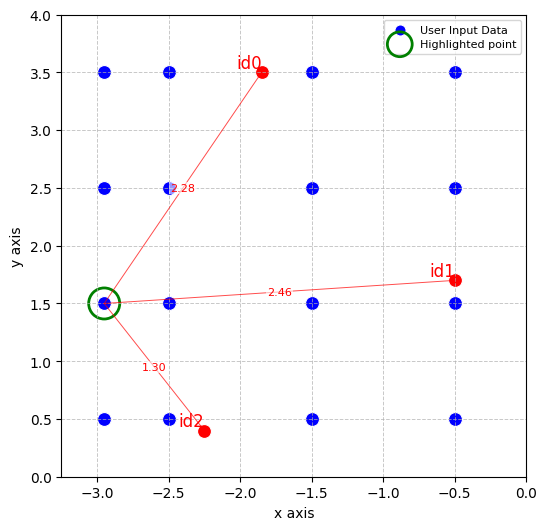

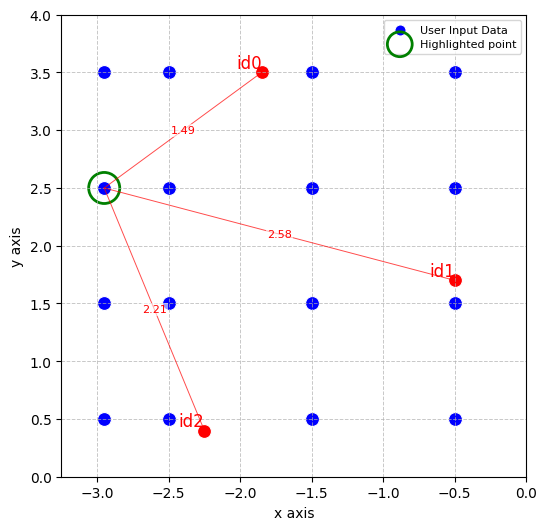

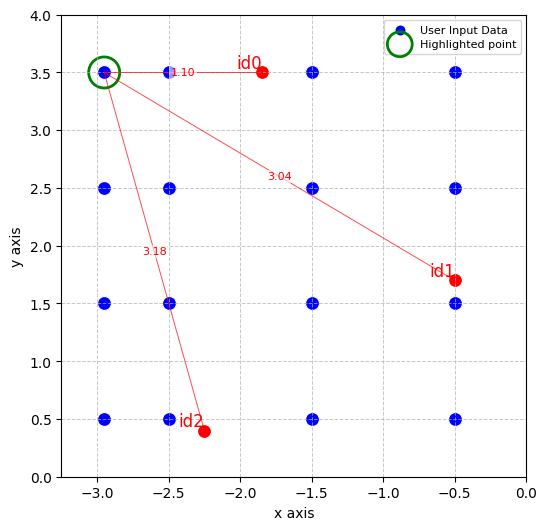

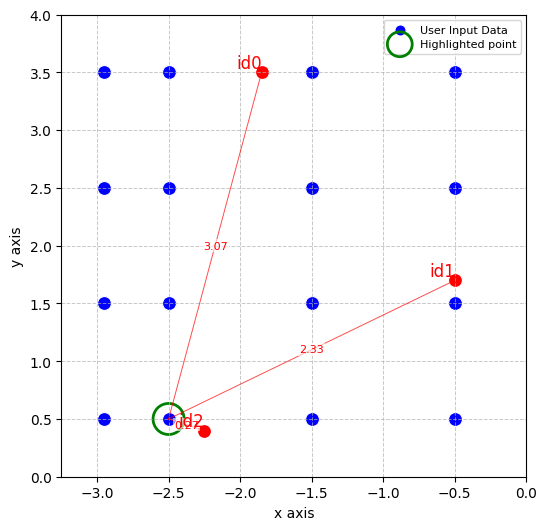

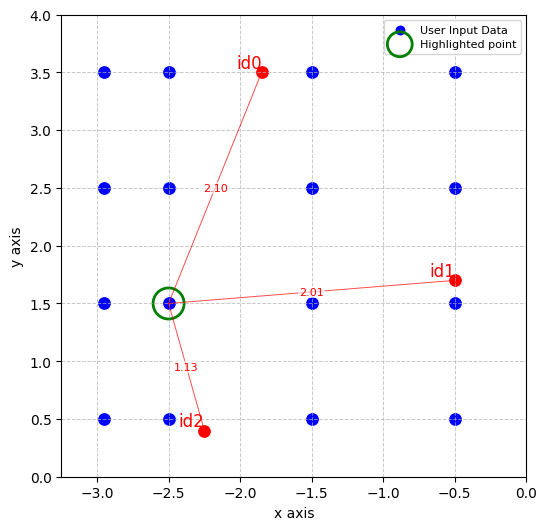

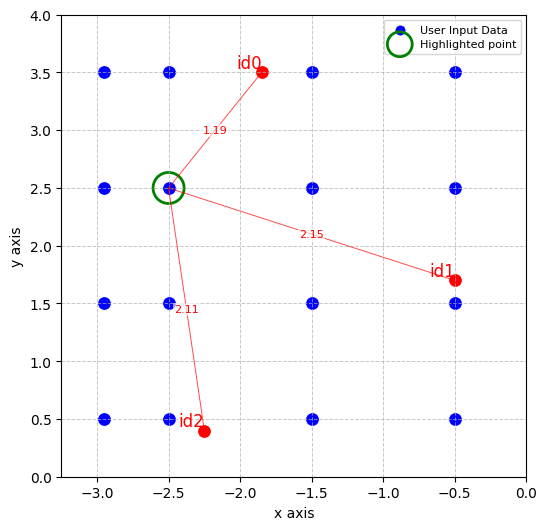

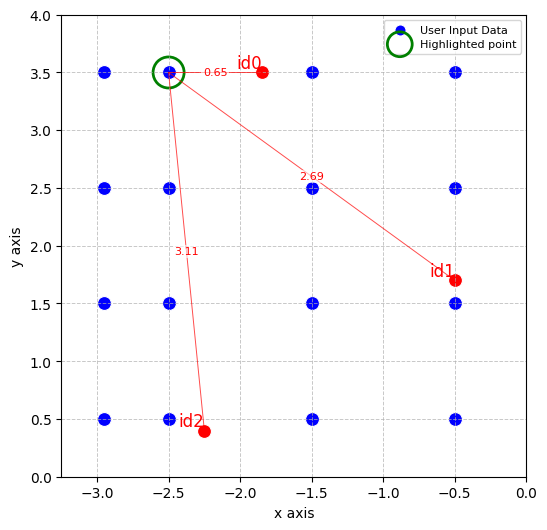

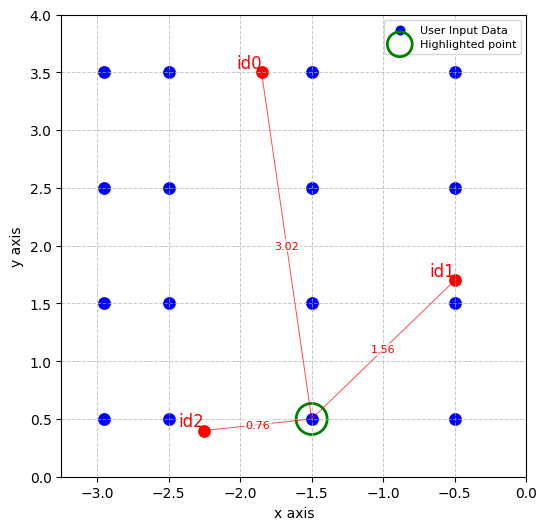

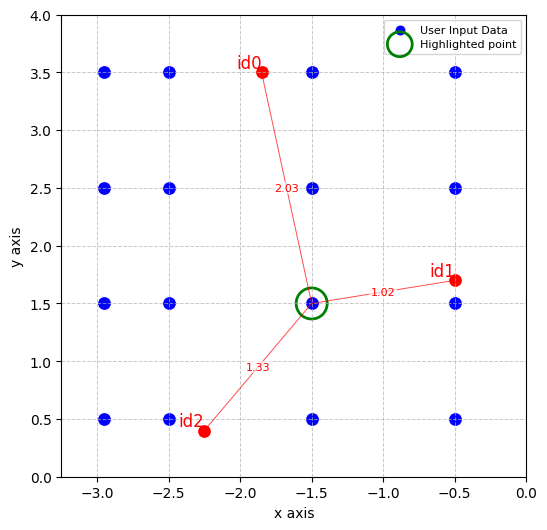

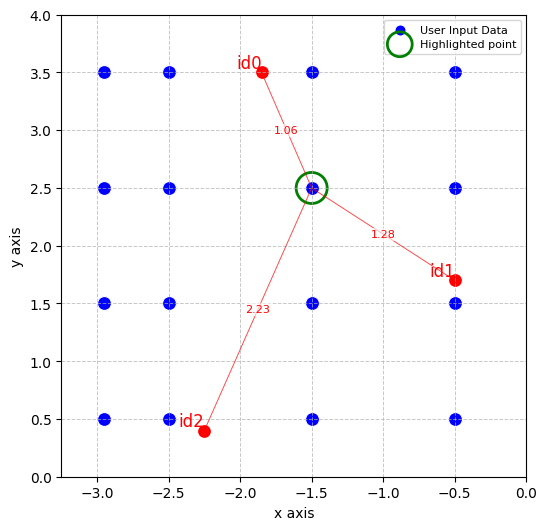

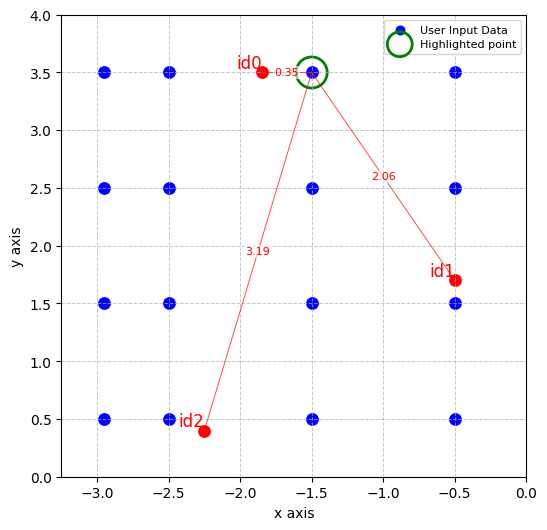

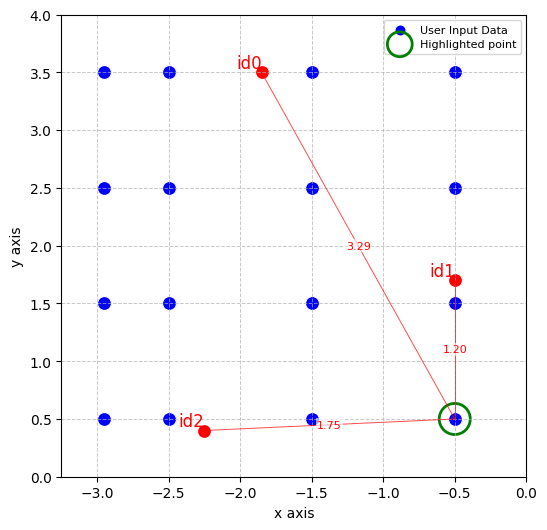

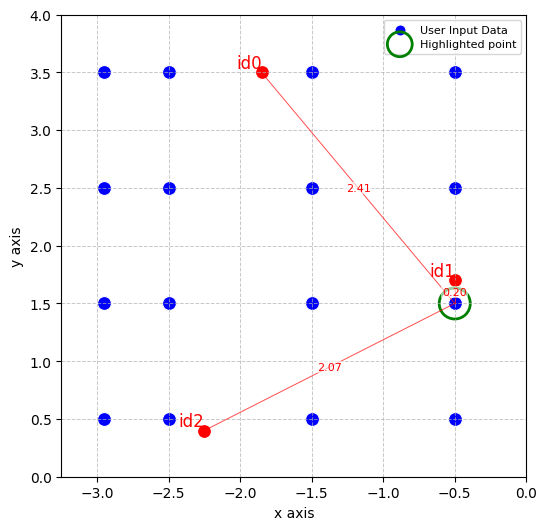

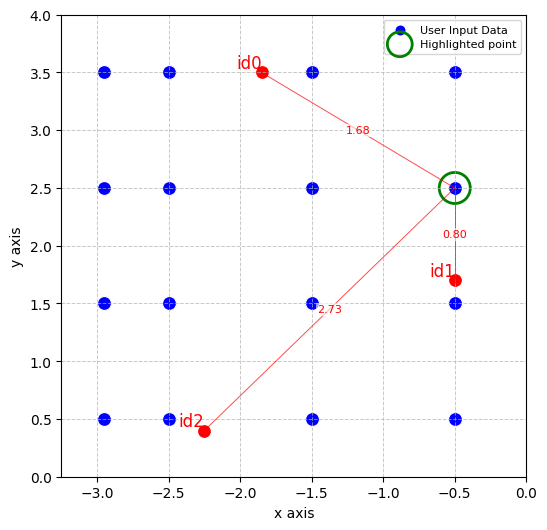

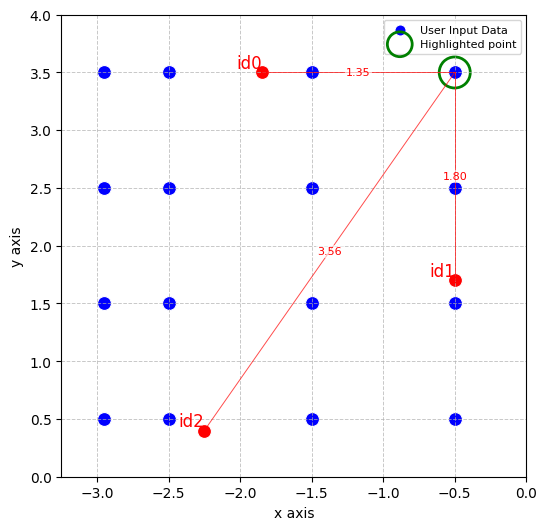

In [26]:
def plot_all_positions(userInputData):
    room_other_grouping = userInputData.groupby(["x axis","y axis"]).groups
    
    for group_name,indexes_of_the_group in room_other_grouping.items(): 
        sample_row_of_the_group = userInputData.loc[indexes_of_the_group[0],:]
        plot_position(userInputData,sample_row_of_the_group)      
        
plot_all_positions(userInputData)

sensors = timeSeriesData_BIG["sensors"].unique()
euclidian_distances_columns = [f"Euclidian distance to {sensor}" for sensor in sensors ]
group_by_list = ["room","experimentState",*euclidian_distances_columns]
room_other_grouping = userInputData.groupby(group_by_list).groups
type_of_other_grouping = ["experimentState","position","distance"]

sensors = timeSeriesData_BIG["sensors"].unique()
for sensor in sensors:
    mask = timeSeriesData_BIG["sensors"] == sensor
    timeSeriesData_BIG_subset = timeSeriesData_BIG.loc[mask,:]
    print(sensor)
    printDataBasedOnDate("VOC",userInputData,timeSeriesData_BIG_subset,room_other_grouping,type_of_other_grouping)

sensors = timeSeriesData_BIG["sensors"].unique()
euclidian_distances_columns = [f"Euclidian distance to {sensor}" for sensor in sensors ]
group_by_list = ["room","experimentState",*euclidian_distances_columns]
room_other_grouping = userInputData.groupby(group_by_list).groups
type_of_other_grouping = ["experimentState","position","distance"]

sensors = timeSeriesData_BIG["sensors"].unique()
for sensor in sensors:
    mask = timeSeriesData_BIG["sensors"] == sensor
    timeSeriesData_BIG_subset = timeSeriesData_BIG.loc[mask,:]
    print(sensor)
    printDataBasedOnDate("VOC rolling average",userInputData,timeSeriesData_BIG_subset,room_other_grouping,type_of_other_grouping)

sensors = timeSeriesData_BIG["sensors"].unique()
euclidian_distances_columns = [f"Euclidian distance to {sensor}" for sensor in sensors ]
group_by_list = ["room","experimentState"]
room_other_grouping = userInputData.groupby(group_by_list).groups
type_of_other_grouping = ["experimentState","date of experiment"]

sensors = timeSeriesData_BIG["sensors"].unique()
for sensor in sensors:
    mask = timeSeriesData_BIG["sensors"] == sensor
    timeSeriesData_BIG_subset = timeSeriesData_BIG.loc[mask,:]
    print(sensor)
    printDataBasedOnDate("VOC rolling average",userInputData,timeSeriesData_BIG_subset,room_other_grouping,type_of_other_grouping)

## MODEL TRAINING

### CREATE THE X AND Y ARRAYS

In [24]:

df_filtered = timeSeriesData_BIG.loc[timeSeriesData_BIG["keys"].isin(userInputData.index)]
dfs_by_sensor = {
    sensor: g
    for sensor, g in df_filtered.groupby("sensors")
}


In [25]:
dfs_by_sensor

{'Id=0:BME680:breathVocEquivalent':          keys                          sensors    VOC  after_insertion  \
 seconds                                                                  
 -30       146  Id=0:BME680:breathVocEquivalent  0.071            False   
 -29       146  Id=0:BME680:breathVocEquivalent  0.073            False   
 -28       146  Id=0:BME680:breathVocEquivalent  0.074            False   
 -27       146  Id=0:BME680:breathVocEquivalent  0.076            False   
 -26       146  Id=0:BME680:breathVocEquivalent  0.078            False   
 ...       ...                              ...    ...              ...   
  295      258  Id=0:BME680:breathVocEquivalent  2.093             True   
  296      258  Id=0:BME680:breathVocEquivalent  2.108             True   
  297      258  Id=0:BME680:breathVocEquivalent  2.114             True   
  298      258  Id=0:BME680:breathVocEquivalent  2.123             True   
  299      258  Id=0:BME680:breathVocEquivalent  2.143           

In [26]:
dfs_by_sensor['Id=0:BME680:breathVocEquivalent'].columns

Index(['keys', 'sensors', 'VOC', 'after_insertion', 'original_value',
       'datetime_timestamp', 'timestamp', 'seconds',
       'seconds passed from insertionSource', 'VOC original',
       'VOC rolling average', 'original seconds', 'VOC-capped',
       'VOC rolling average-capped', 'VOC gradient',
       'VOC rolling average gradient',
       'VOC rolling average standard scaler whole experiment',
       'VOC rolling average-capped standard scaler whole experiment'],
      dtype='object')

In [27]:
sensors = timeSeriesData_BIG["sensors"].unique()

euclidian_distances_columns = [f"Euclidian distance to {sensor}" for sensor in sensors ]
userInputData.loc[:,euclidian_distances_columns] = userInputData.loc[:,euclidian_distances_columns].round(2)

In [28]:
print(userInputData["x-y axis"].unique())

[(-2.95, 2.5) (-2.95, 3.5) (-0.5, 3.5) (-0.5, 2.5) (-0.5, 1.5) (-0.5, 0.5)
 (-1.5, 0.5) (-1.5, 1.5) (-1.5, 2.5) (-1.5, 3.5) (-2.5, 3.5) (-2.5, 2.5)
 (-2.5, 1.5) (-2.5, 0.5) (-2.95, 0.5) (-2.95, 1.5)]


In [29]:
columns_to_keep = ["VOC rolling average"]

key_to_grab_size = userInputData.index[0]
mask = dfs_by_sensor['Id=0:BME680:breathVocEquivalent']["keys"] == key_to_grab_size

sample_data = dfs_by_sensor['Id=0:BME680:breathVocEquivalent'].loc[mask,columns_to_keep]
print(sample_data.shape[0])


330


In [30]:
from sklearn.preprocessing import LabelEncoder

columns_to_create_X_data = "VOC rolling average"

column_to_create_Y_data = "x-y axis"

sensors = timeSeriesData_BIG["sensors"].unique()
X ={}
Y ={}

#grab the number of features

key_to_grab_size = userInputData.index[0]
mask = dfs_by_sensor['Id=0:BME680:breathVocEquivalent']["keys"] == key_to_grab_size

sample_data = dfs_by_sensor['Id=0:BME680:breathVocEquivalent'].loc[mask,columns_to_create_X_data]
X_subset_columns_size = sample_data.shape[0]

dict_flattened_arrays_per_sensor_per_distance ={}
for sensor in sensors:
    X[sensor] = np.empty((0, X_subset_columns_size))
    Y_as_string = pd.Series(np.empty(0, dtype=object))
    dict_flattened_arrays_per_sensor_per_distance[sensor] = {}
    
    for X_Y_axis,experiments in userInputData.groupby(column_to_create_Y_data):
        
        rows_size = experiments.shape[0]
        Y_distance_subset = pd.Series(np.empty(rows_size, dtype=object))
        X_distance_subset = np.empty((rows_size,X_subset_columns_size))
        
        X_Y_axis_string = str(X_Y_axis[0]) +"_"+str(X_Y_axis[1])
        Y_distance_subset[:] = X_Y_axis_string
        Y_as_string = pd.concat([Y_as_string, pd.Series(Y_distance_subset, dtype=object)], ignore_index=True)
        
             
        for array_index,experiment_index in enumerate(experiments.index):
          
            mask = dfs_by_sensor[sensor]["keys"]== experiment_index
            flatten_array = dfs_by_sensor[sensor].loc[mask,columns_to_create_X_data].to_numpy().reshape(1, -1)
            
            X_distance_subset[array_index,:] =   flatten_array
            
        X[sensor] = np.vstack((X[sensor],X_distance_subset))  
    print(Y_as_string)
    le = LabelEncoder()
    Y[sensor] =  le.fit_transform(Y_as_string)     



0     -2.95_0.5
1     -2.95_0.5
2     -2.95_0.5
3     -2.95_0.5
4     -2.95_0.5
        ...    
93     -0.5_3.5
94     -0.5_3.5
95     -0.5_3.5
96     -0.5_3.5
97     -0.5_3.5
Length: 98, dtype: object
0     -2.95_0.5
1     -2.95_0.5
2     -2.95_0.5
3     -2.95_0.5
4     -2.95_0.5
        ...    
93     -0.5_3.5
94     -0.5_3.5
95     -0.5_3.5
96     -0.5_3.5
97     -0.5_3.5
Length: 98, dtype: object
0     -2.95_0.5
1     -2.95_0.5
2     -2.95_0.5
3     -2.95_0.5
4     -2.95_0.5
        ...    
93     -0.5_3.5
94     -0.5_3.5
95     -0.5_3.5
96     -0.5_3.5
97     -0.5_3.5
Length: 98, dtype: object


In [31]:
X

{'Id=2:BME680:breathVocEquivalent': array([[ 0.1828,  0.1855,  0.1878, ...,  2.8785,  2.8719,  2.8653],
        [ 0.056 ,  0.0561,  0.0563, ...,  5.4566,  5.4663,  5.4707],
        [ 0.3193,  0.3103,  0.3015, ..., 10.522 , 10.1893,  9.8821],
        ...,
        [ 0.0198,  0.0195,  0.0192, ...,  0.1088,  0.1091,  0.1094],
        [ 0.7046,  0.7062,  0.7077, ...,  1.4208,  1.4214,  1.4229],
        [ 0.5331,  0.5526,  0.5713, ...,  4.9652,  4.9796,  4.9923]]),
 'Id=0:BME680:breathVocEquivalent': array([[0.2349, 0.2418, 0.2481, ..., 2.4896, 2.5119, 2.535 ],
        [0.0222, 0.0232, 0.0244, ..., 1.5088, 1.5009, 1.4933],
        [0.0304, 0.0287, 0.0269, ..., 0.7596, 0.763 , 0.7658],
        ...,
        [0.0056, 0.0061, 0.0065, ..., 0.095 , 0.0949, 0.0949],
        [0.0646, 0.0694, 0.0741, ..., 1.6063, 1.6113, 1.6164],
        [1.1013, 1.1051, 1.1079, ..., 2.7677, 2.7589, 2.7503]]),
 'Id=1:BME680:breathVocEquivalent': array([[0.2665, 0.2744, 0.2826, ..., 1.9292, 1.9192, 1.9083],
        [0

In [32]:
Y

{'Id=2:BME680:breathVocEquivalent': array([12, 12, 12, 12, 12, 12, 13, 13, 13, 13, 13, 13, 14, 14, 14, 14, 14,
        14, 14, 15, 15, 15, 15, 15, 15, 15,  8,  8,  8,  8,  8,  8,  9,  9,
         9,  9,  9,  9, 10, 10, 10, 10, 10, 10, 11, 11, 11, 11, 11, 11,  4,
         4,  4,  4,  4,  4,  5,  5,  5,  5,  5,  5,  6,  6,  6,  6,  6,  6,
         7,  7,  7,  7,  7,  7,  0,  0,  0,  0,  0,  0,  1,  1,  1,  1,  1,
         1,  2,  2,  2,  2,  2,  2,  3,  3,  3,  3,  3,  3]),
 'Id=0:BME680:breathVocEquivalent': array([12, 12, 12, 12, 12, 12, 13, 13, 13, 13, 13, 13, 14, 14, 14, 14, 14,
        14, 14, 15, 15, 15, 15, 15, 15, 15,  8,  8,  8,  8,  8,  8,  9,  9,
         9,  9,  9,  9, 10, 10, 10, 10, 10, 10, 11, 11, 11, 11, 11, 11,  4,
         4,  4,  4,  4,  4,  5,  5,  5,  5,  5,  5,  6,  6,  6,  6,  6,  6,
         7,  7,  7,  7,  7,  7,  0,  0,  0,  0,  0,  0,  1,  1,  1,  1,  1,
         1,  2,  2,  2,  2,  2,  2,  3,  3,  3,  3,  3,  3]),
 'Id=1:BME680:breathVocEquivalent': array([12,

In [33]:
X.keys()

dict_keys(['Id=2:BME680:breathVocEquivalent', 'Id=0:BME680:breathVocEquivalent', 'Id=1:BME680:breathVocEquivalent'])

### DISCOVER POTENTIAL DIMENSIONALITY REDUCTION

In [34]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

Id=0:BME680:breathVocEquivalent
{'copy': True, 'with_mean': True, 'with_std': True}


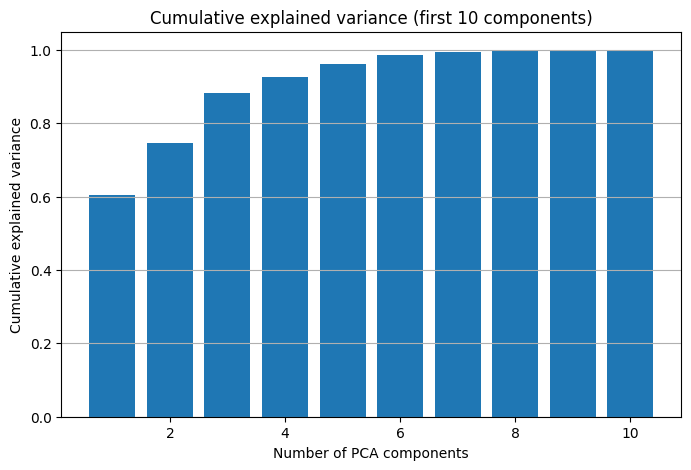

Optimal number of components to explain ~90% variance: 4
Id=1:BME680:breathVocEquivalent
{'copy': True, 'with_mean': True, 'with_std': True}


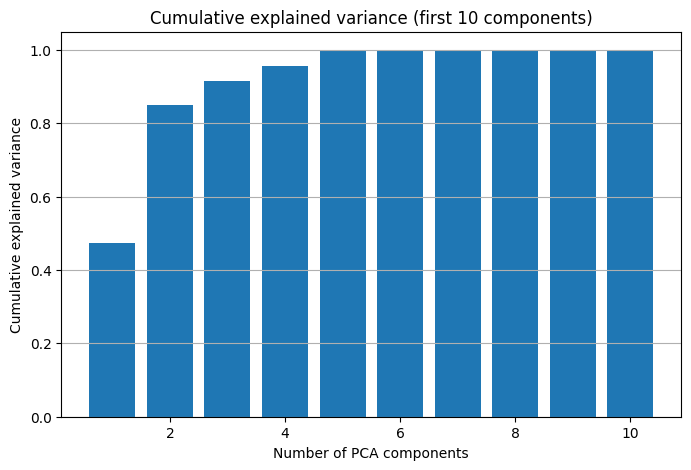

Optimal number of components to explain ~90% variance: 3
Id=2:BME680:breathVocEquivalent
{'copy': True, 'with_mean': True, 'with_std': True}


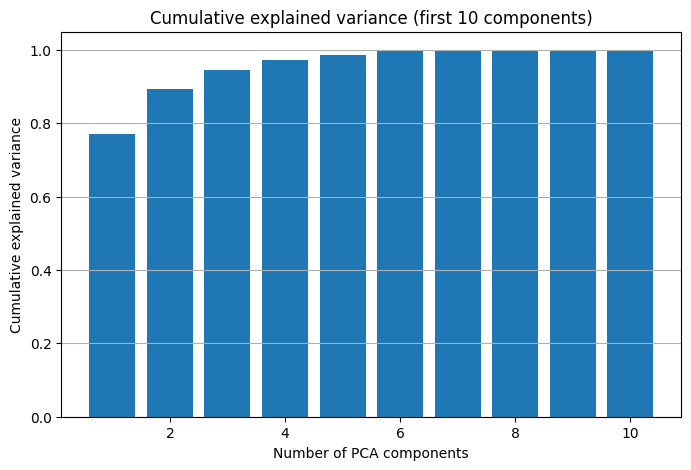

Optimal number of components to explain ~90% variance: 3


In [38]:


sensor_names = ['Id=0:BME680:breathVocEquivalent','Id=1:BME680:breathVocEquivalent','Id=2:BME680:breathVocEquivalent']


for sensor_name in sensor_names:
    print(sensor_name)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X[sensor_name])
    print(scaler.get_params())
    # Step 2: Apply PCA
    pca = PCA()
    X_pca = pca.fit_transform(X_scaled)
    
    # Step 3: Explained variance
    explained_variance = pca.explained_variance_ratio_
    cumulative_variance = np.cumsum(explained_variance)
    
    # Only display first 10 components max
    max_components = min(10, len(explained_variance))
    ev_to_plot = explained_variance[:max_components]
    cum_to_plot = cumulative_variance[:max_components]
    
    # Step 4: Bar plot of cumulative explained variance
    plt.figure(figsize=(8,5))
    plt.bar(range(1, max_components + 1), cum_to_plot)
    plt.xlabel('Number of PCA components')
    plt.ylabel('Cumulative explained variance')
    plt.title('Cumulative explained variance (first 10 components)')
    plt.grid(True, axis='y')
    plt.show()
    
    # Step 5: Optimal number of components for ~90% variance
    optimal_components = np.argmax(cumulative_variance >= 0.90) + 1
    print("Optimal number of components to explain ~90% variance:", optimal_components)


### SEARCH BEST MODEL OF EACH INDIVIDUAL SENSOR'S X AND Y AXIS

In [35]:
# Required imports
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier

from sklearn.pipeline import Pipeline

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error,mean_absolute_error, r2_score


In [42]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier

# 1. Logistic Regression
logreg = LogisticRegression(max_iter=5000)
logreg_params = {
    "C": [0.01, 0.1, 1, 10, 100],
    "penalty": ["l2"],          # 'l1' requires solver='liblinear' or 'saga'
    "solver": ["lbfgs", "saga"]
}

# 2. Support Vector Classifier
svc = SVC()
svc_params = {
    "kernel": ["rbf", "poly", "sigmoid"],
    "C": [0.1, 1, 10, 100],
    "gamma": ["scale", "auto"]
}

# 3. K-Nearest Neighbors
knn = KNeighborsClassifier()
knn_params = {
    "n_neighbors": [3, 5, 7, 9],
    "weights": ["uniform", "distance"],
    "metric": ["euclidean", "manhattan"]
}

# 4. Decision Tree Classifier
dt = DecisionTreeClassifier()
dt_params = {
    "max_depth": [None, 5, 10, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

# 5. Random Forest Classifier
rf = RandomForestClassifier(random_state=42)
rf_params = {
    "n_estimators": [50, 100, 200],
    "max_depth": [None, 5, 10, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

# 6. Gradient Boosting Classifier
gbc = GradientBoostingClassifier()
gbc_params = {
    "n_estimators": [50, 100, 200],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "max_depth": [3, 5],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

# 7. Neural Network (MLPClassifier)
mlp = MLPClassifier(max_iter=3000)
mlp_params = {
    "hidden_layer_sizes": [(50,), (100,), (100, 50)],
    "activation": ["relu", "tanh"],
    "alpha": [0.0001, 0.001, 0.01],
    "learning_rate_init": [0.001, 0.01]
}


# Combine them into your expected dictionary:
models = {
    "LogisticRegression": (logreg, logreg_params),
    "SVC": (svc, svc_params),
    "KNN": (knn, knn_params),
    "DecisionTree": (dt, dt_params),
    "RandomForest": (rf, rf_params),
    #"GradientBoosting": (gbc, gbc_params),
    "MLPClassifier": (mlp, mlp_params),
}

# PCA components (same as your regression example)
PCA__n_components = [3, 4, 6, 8, 10]


In [43]:


def run_grid_search_per_model(X_train, y_train, cv_number, verbose,
                              name, model, params, PCA__n_components):

    # Models that should NOT use scaling or PCA
    estimators_with_no_scaling_need = [
        'RandomForest',
        'DecisionTree',
        'GradientBoosting'
    ]

    results = {}

    # Select pipeline structure
    # if name in estimators_with_no_scaling_need:
    #     pipe = Pipeline([
    #         ('model', model)
    #     ])
    # else:
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('PCA', PCA()),
        ('model', model)
    ])

    # Build parameter grid for GridSearchCV
    param_grid = { 'model__' + k: v for k, v in params.items() }

    if name not in estimators_with_no_scaling_need:
        param_grid['PCA__n_components'] = PCA__n_components

    # ---- CLASSIFICATION SCORING ----
    grid = GridSearchCV(
        estimator=pipe,
        param_grid=param_grid,
        cv=cv_number,
        n_jobs=-1,
        scoring='accuracy',      # 👈 CHANGED FOR CLASSIFICATION
        verbose=verbose
    )

    grid.fit(X_train, y_train)

    # Save results
    results["name"] = name
    results["model"] = grid.best_estimator_
    results["parameters"] = grid.best_params_
    results["score"] = grid.best_score_

    return results


def run_grid_search_find_optimal_model_per_sensor(
        X_train, y_train, cv_number, verbose, models, PCA__n_components):

    best_result = {
        "score": -1e9,
        "model": None,
        "parameters": {},
        "name": ""
    }

    for name, (model, params) in models.items():
        print(f"\nRunning GridSearchCV for {name}...")

        results = run_grid_search_per_model(
            X_train, y_train, cv_number, verbose,
            name, model, params, PCA__n_components
        )

        print(results)

        # Keep best classification score
        if results["score"] > best_result["score"]:
            best_result["name"] = results["name"]
            best_result["score"] = results["score"]
            best_result["model"] = results["model"]
            best_result["parameters"] = results["parameters"]

            print(f"Current BEST → {best_result['name']} | score={best_result['score']}")

    return best_result


In [44]:
sensor_names = [
    "Id=0:BME680:breathVocEquivalent",
    "Id=1:BME680:breathVocEquivalent",
    "Id=2:BME680:breathVocEquivalent"    
]

test_size = 0.2         # number of data taken
random_state = 42         # predefined random state for reproducibility
cv_number = 5
verbose =2
best_result_per_sensor = {}
for sensor_name in sensor_names:
    X_arr = np.asarray(X[sensor_name])
    Y_arr = np.asarray(Y[sensor_name])
    

    # --- Train/test split ---
    X_train, X_test, y_train, y_test = train_test_split(
        X_arr, Y_arr,
        test_size=0.16,
        stratify=Y_arr,
        random_state=42
    )
    print(y_test)
    best_result_per_sensor[sensor_name] = run_grid_search_find_optimal_model_per_sensor(X_train,y_train,cv_number,verbose,models,PCA__n_components)

[ 0 13 14  7 15  3 12  4  8  9  1 11  5  2 10  6]

Running GridSearchCV for LogisticRegression...
Fitting 5 folds for each of 50 candidates, totalling 250 fits
{'name': 'LogisticRegression', 'model': Pipeline(steps=[('scaler', StandardScaler()), ('PCA', PCA(n_components=3)),
                ('model', LogisticRegression(C=0.01, max_iter=5000))]), 'parameters': {'PCA__n_components': 3, 'model__C': 0.01, 'model__penalty': 'l2', 'model__solver': 'lbfgs'}, 'score': 0.1463235294117647}
Current BEST → LogisticRegression | score=0.1463235294117647

Running GridSearchCV for SVC...
Fitting 5 folds for each of 120 candidates, totalling 600 fits
{'name': 'SVC', 'model': Pipeline(steps=[('scaler', StandardScaler()), ('PCA', PCA(n_components=8)),
                ('model', SVC(C=100, gamma='auto', kernel='sigmoid'))]), 'parameters': {'PCA__n_components': 8, 'model__C': 100, 'model__gamma': 'auto', 'model__kernel': 'sigmoid'}, 'score': 0.15882352941176472}
Current BEST → SVC | score=0.1588235294117647

C:\Python311\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (3000) reached and the optimization hasn't converged yet.
  warnings.warn(


{'name': 'MLPClassifier', 'model': Pipeline(steps=[('scaler', StandardScaler()), ('PCA', PCA(n_components=3)),
                ('model',
                 MLPClassifier(hidden_layer_sizes=(50,), max_iter=3000))]), 'parameters': {'PCA__n_components': 3, 'model__activation': 'relu', 'model__alpha': 0.0001, 'model__hidden_layer_sizes': (50,), 'model__learning_rate_init': 0.001}, 'score': 0.1713235294117647}
Current BEST → MLPClassifier | score=0.1713235294117647
[ 0 13 14  7 15  3 12  4  8  9  1 11  5  2 10  6]

Running GridSearchCV for LogisticRegression...
Fitting 5 folds for each of 50 candidates, totalling 250 fits
{'name': 'LogisticRegression', 'model': Pipeline(steps=[('scaler', StandardScaler()), ('PCA', PCA(n_components=6)),
                ('model', LogisticRegression(C=100, max_iter=5000))]), 'parameters': {'PCA__n_components': 6, 'model__C': 100, 'model__penalty': 'l2', 'model__solver': 'lbfgs'}, 'score': 0.1463235294117647}
Current BEST → LogisticRegression | score=0.1463235294

In [51]:
best_result_per_sensor

{'Id=0:BME680:breathVocEquivalent': {'score': 0.1713235294117647,
  'model': Pipeline(steps=[('scaler', StandardScaler()), ('PCA', PCA(n_components=3)),
                  ('model',
                   MLPClassifier(hidden_layer_sizes=(50,), max_iter=3000))]),
  'parameters': {'PCA__n_components': 3,
   'model__activation': 'relu',
   'model__alpha': 0.0001,
   'model__hidden_layer_sizes': (50,),
   'model__learning_rate_init': 0.001},
  'name': 'MLPClassifier'},
 'Id=1:BME680:breathVocEquivalent': {'score': 0.15882352941176472,
  'model': Pipeline(steps=[('scaler', StandardScaler()), ('PCA', PCA()),
                  ('model',
                   DecisionTreeClassifier(max_depth=20, min_samples_leaf=2,
                                          min_samples_split=5))]),
  'parameters': {'model__max_depth': 20,
   'model__min_samples_leaf': 2,
   'model__min_samples_split': 5},
  'name': 'DecisionTree'},
 'Id=2:BME680:breathVocEquivalent': {'score': 0.17205882352941176,
  'model': Pipeline(

### SEE RESULTS

In [51]:
def plot_pred_vs_actual(y_test, y_pred,sensor_name,AXIS):
    # --- Plot: predicted vs actual ---
    mse = mean_squared_error(y_test, y_pred)
    
    r2  = r2_score(y_test, y_pred)
    #check if a numpy array is 1D,if yes,make it 2D with one n,1
    if y_test.ndim == 1:
       y_test =  y_test.reshape(-1,1)
    if y_pred.ndim == 1:
       y_pred =  y_pred.reshape(-1,1)   

    EucDis = np.linalg.norm(y_test - y_pred,axis=1).mean()
    print(f"MSE on test set: {mse:.4f}")
    
    print(f"R^2 on test set: {r2:.4f}")

    print(f"Euclidian distance median value {EucDis:.4f}")
  

    if (y_test.shape[1] == 1) and (y_pred.shape[1] == 1):
        plt.figure(figsize=(7,6))
        plt.scatter(y_test, y_pred, s=50)
        plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], linestyle='--')
        plt.xlabel("True target")
        plt.ylabel("Predicted target")
        plt.title(f"{sensor_name} {AXIS} predictions vs actual")
        plt.grid(True)
        plt.show()

    else:
        # --- Plot ---
        plt.scatter(y_test[:,0], y_test[:,1], label="True", alpha=0.6)
        plt.scatter(y_pred[:,0], y_pred[:,1], label="Predicted", alpha=0.6)
        plt.legend()
        plt.xlabel("X")
        plt.ylabel("Y")
        plt.title("True vs Predicted Positions")
        plt.grid(True)
        plt.show()


MSE on test set: 0.9614
R^2 on test set: -0.0168
Euclidian distance median value 0.9132


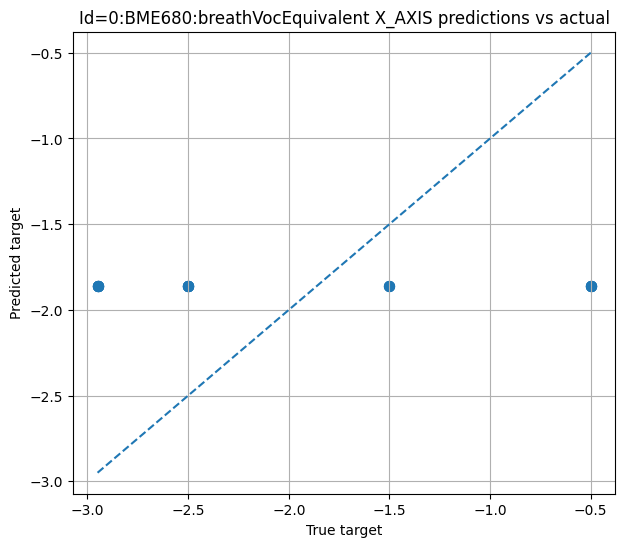

MSE on test set: 1.6065
R^2 on test set: -0.2956
Euclidian distance median value 1.0355


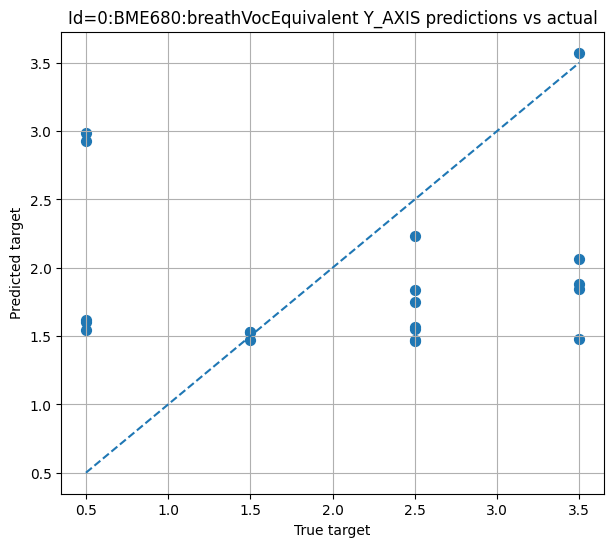

MSE on test set: 1.1492
R^2 on test set: -0.2154
Euclidian distance median value 0.9185


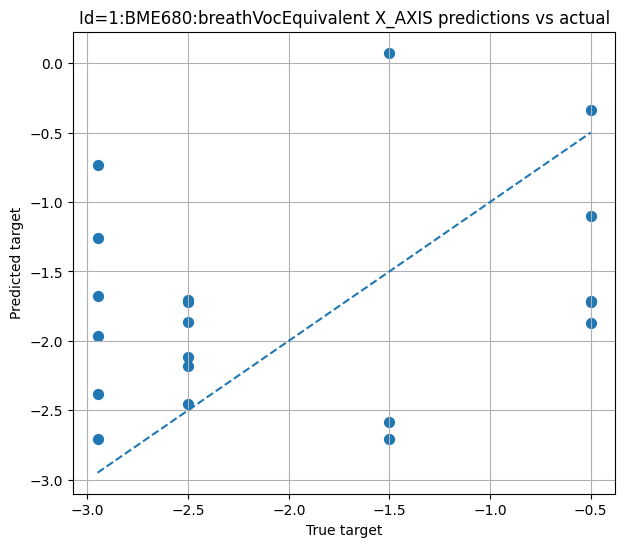

MSE on test set: 1.2500
R^2 on test set: -0.0081
Euclidian distance median value 1.0000


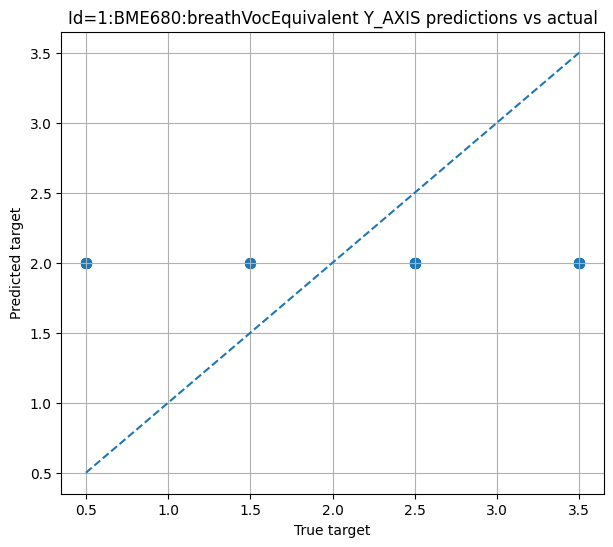

MSE on test set: 0.9236
R^2 on test set: 0.0231
Euclidian distance median value 0.8564


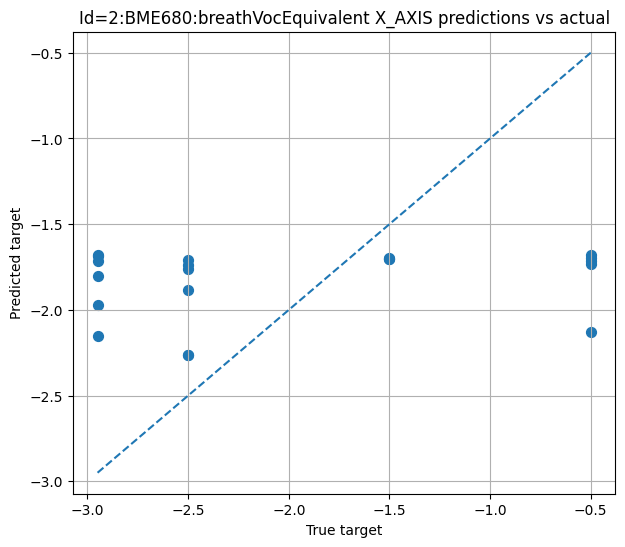

MSE on test set: 1.2263
R^2 on test set: 0.0111
Euclidian distance median value 0.9418


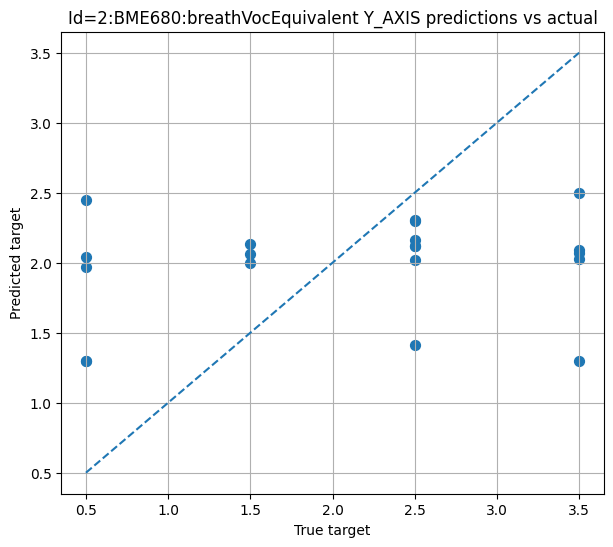

In [52]:
#PREDICT AND SEE INDIVIDUAL RESULTS
PREDICT_X_AXIS = {}
PREDICT_Y_AXIS = {}
PREDICT_POSITION_VALUE = {}
for sensor_name in sensor_names:
    #predict x axis
    PREDICT_X_AXIS[sensor_name] = best_result_per_sensor[sensor_name]["model"].predict(X_AXIS_X_TEST[sensor_name])

    plot_pred_vs_actual(X_AXIS_Y_TEST[sensor_name],PREDICT_X_AXIS[sensor_name],sensor_name,"X_AXIS")

    #predict y axis

    PREDICT_Y_AXIS[sensor_name] = best_result_per_sensor[sensor_name]["model"].predict(Y_AXIS_X_TEST[sensor_name])

    plot_pred_vs_actual(Y_AXIS_Y_TEST[sensor_name],PREDICT_Y_AXIS[sensor_name],sensor_name,"Y_AXIS")
    PREDICT_POSITION_VALUE[sensor_name] =  np.column_stack(( PREDICT_X_AXIS[sensor_name], PREDICT_Y_AXIS[sensor_name]))


GRAB THE MEDIAN OF EACH REGRESSOR

MSE on test set: 1.0553
R^2 on test set: 0.0382
Euclidian distance median value 1.3871


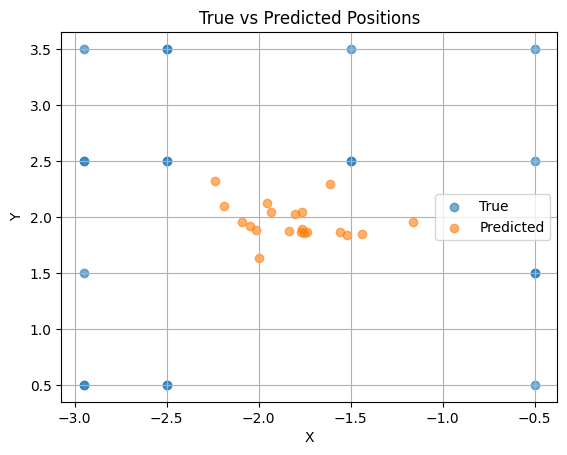

In [53]:
# PREDICTION_VALUES_MEDIAN = {
#     "MSE": '',
#     "R2" : '',
#     "Median Euclidian Distance":''

# }
sensor_names = [
    "Id=0:BME680:breathVocEquivalent",
    "Id=1:BME680:breathVocEquivalent",
    "Id=2:BME680:breathVocEquivalent"    
]
#the random state is the same, so we know they have they same amount taken from y test and afterwars, they have the same amount of elements.
POSITION_Y_TRAIN = np.column_stack((X_AXIS_Y_TRAIN[sensor_names[0]],Y_AXIS_Y_TRAIN[sensor_names[0]]))
POSITION_Y_TEST  = np.column_stack((X_AXIS_Y_TEST[sensor_names[0]],Y_AXIS_Y_TEST[sensor_names[0]]))
row_number = POSITION_Y_TEST.shape[0]
PREDICT_POSITION_VALUE = np.empty((row_number, 2)) 

PREDICT_POSITION_VALUE[:,0] = np.column_stack(([column for column in PREDICT_X_AXIS.values()])).mean(axis=1)

PREDICT_POSITION_VALUE[:,1] = np.column_stack(([column for column in PREDICT_Y_AXIS.values()])).mean(axis=1)

plot_pred_vs_actual(POSITION_Y_TEST, PREDICT_POSITION_VALUE,sensor_names,"X-Y AXIS")

### TRAIN A STACKED REGRESSION MODEL 

In [52]:
from sklearn.ensemble import StackingClassifier

In [53]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier

# 1. Logistic Regression
logreg = LogisticRegression(max_iter=5000)
logreg_params = {
    "C": [0.01, 0.1, 1, 10, 100],
    "penalty": ["l2"],          # 'l1' requires solver='liblinear' or 'saga'
    "solver": ["lbfgs", "saga"]
}

# 2. Support Vector Classifier
svc = SVC()
svc_params = {
    "kernel": ["rbf", "poly", "sigmoid"],
    "C": [0.1, 1, 10, 100],
    "gamma": ["scale", "auto"]
}

# 3. K-Nearest Neighbors
knn = KNeighborsClassifier()
knn_params = {
    "n_neighbors": [3, 5, 7, 9],
    "weights": ["uniform", "distance"],
    "metric": ["euclidean", "manhattan"]
}

# 4. Decision Tree Classifier
dt = DecisionTreeClassifier()
dt_params = {
    "max_depth": [None, 5, 10, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

# 5. Random Forest Classifier
rf = RandomForestClassifier(random_state=42)
rf_params = {
    "n_estimators": [50, 100, 200],
    "max_depth": [None, 5, 10, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

# 6. Gradient Boosting Classifier
gbc = GradientBoostingClassifier()
gbc_params = {
    "n_estimators": [50, 100, 200],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "max_depth": [3, 5],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

# 7. Neural Network (MLPClassifier)
mlp = MLPClassifier(max_iter=3000)
mlp_params = {
    "hidden_layer_sizes": [(50,), (100,), (100, 50)],
    "activation": ["relu", "tanh"],
    "alpha": [0.0001, 0.001, 0.01],
    "learning_rate_init": [0.001, 0.01]
}


# Combine them into your expected dictionary:
models = {
    "LogisticRegression": (logreg, logreg_params),
    "SVC": (svc, svc_params),
    "KNN": (knn, knn_params),
    "DecisionTree": (dt, dt_params),
    "RandomForest": (rf, rf_params),
 #   "GradientBoosting": (gbc, gbc_params),
    "MLPClassifier": (mlp, mlp_params),
}

# PCA components (same as your regression example)
PCA__n_components = [3, 4, 6, 8, 10]


In [46]:
best_result_per_sensor

{'Id=0:BME680:breathVocEquivalent': {'score': 0.1713235294117647,
  'model': Pipeline(steps=[('scaler', StandardScaler()), ('PCA', PCA(n_components=3)),
                  ('model',
                   MLPClassifier(hidden_layer_sizes=(50,), max_iter=3000))]),
  'parameters': {'PCA__n_components': 3,
   'model__activation': 'relu',
   'model__alpha': 0.0001,
   'model__hidden_layer_sizes': (50,),
   'model__learning_rate_init': 0.001},
  'name': 'MLPClassifier'},
 'Id=1:BME680:breathVocEquivalent': {'score': 0.15882352941176472,
  'model': Pipeline(steps=[('scaler', StandardScaler()), ('PCA', PCA()),
                  ('model',
                   DecisionTreeClassifier(max_depth=20, min_samples_leaf=2,
                                          min_samples_split=5))]),
  'parameters': {'model__max_depth': 20,
   'model__min_samples_leaf': 2,
   'model__min_samples_split': 5},
  'name': 'DecisionTree'},
 'Id=2:BME680:breathVocEquivalent': {'score': 0.17205882352941176,
  'model': Pipeline(

In [47]:
import itertoolsc

In [54]:
def find_best_stacked_regression(models,best_models):
    
    best_result = {
        "score" : -10,
        "model" : '',
        "parameters" : {} 
    }
    
    for final_estimator_name, (final_estimator_model, final_estimator_params) in models.items():
        sensor_models_lists = [
            list(models_for_sensor.items())
            for models_for_sensor in best_models.values()
        ]
        for base_estimators_combination in itertools.product(*sensor_models_lists):
            
            base_estimators = [
                (f"{item[0]}_{i}", item[1]["model"])
                for i, item in enumerate(base_estimators_combination)
            ]
           # print(f"base_estimators{base_estimators}")
            stacked_Estimator = StackingRegressor(
                estimators=base_estimators,
                final_estimator=final_estimator_model,  # we will tune this
                passthrough=True           # include original features if you want
            )
            param_grid = {
                **{'final_estimator' +'__' + k: v for k, v in final_estimator_params.items()}
            }
            print(f"final_estimator_model{stacked_Estimator}")
            print(f"param_grid{param_grid}")
            stacked_grid = GridSearchCV(stacked_Estimator,param_grid,cv=5,verbose=2,n_jobs=-1,scoring='accuracy')
            stacked_grid.fit(X_train, y_train)
        
            
            if stacked_grid.best_score_ > best_result["score"]:
                    print(stacked_grid.best_estimator_)
                    best_result["name"]  = stacked_grid
                    best_result["model"] = stacked_grid.best_estimator_
                    best_result["parameters"] = stacked_grid.best_params_
                    best_result["score"] = stacked_grid.best_score_ 
    return  best_result           

In [55]:
def find_best_stacked_Clasification_Pre_Given(models,best_result_per_sensor):
    
    best_result = {
        "score" : -10,
        "model" : '',
        "parameters" : {} 
    }
    
    for final_estimator_name, (final_estimator_model, final_estimator_params) in models.items():
        for base_best_result in best_result_per_sensor.values():
            print(f"b {base_best_result['model']}")
        base_estimators = [(sensor_names,base_best_result['model']) 
                           for sensor_names,base_best_result in best_result_per_sensor.items()]
        print(f"base_estimators:{base_estimators}")
    
       # print(f"base_estimators{base_estimators}")
        stacked_Estimator = StackingClassifier(
            estimators=base_estimators,
            final_estimator=final_estimator_model,  # we will tune this
            passthrough=True           # include original features if you want
        )
        param_grid = {
            **{'final_estimator' +'__' + k: v for k, v in final_estimator_params.items()}
        }
      
        stacked_grid = GridSearchCV(stacked_Estimator,param_grid,cv=5,verbose=2,n_jobs=-1,scoring='accuracy')
        stacked_grid.fit(X_train, y_train)
    
        
        if stacked_grid.best_score_ > best_result["score"]:
                print(stacked_grid.best_estimator_)
                best_result["name"]  = final_estimator_name
                best_result["model"] = stacked_grid.best_estimator_
                best_result["parameters"] = stacked_grid.best_params_
                best_result["score"] = stacked_grid.best_score_ 
    return  best_result           

In [58]:
X_arr = np.asarray(X[sensor_name])
Y_arr = np.asarray(Y[sensor_name])

# --- Train/test split ---
X_train, X_test, y_train, y_test = train_test_split(
    X_arr, Y_arr,
    test_size=0.16,
    stratify=Y_arr,
    random_state=42
)
best_result_Stacked = find_best_stacked_Clasification_Pre_Given(models,best_result_per_sensor)

b Pipeline(steps=[('scaler', StandardScaler()), ('PCA', PCA(n_components=3)),
                ('model',
                 MLPClassifier(hidden_layer_sizes=(50,), max_iter=3000))])
b Pipeline(steps=[('scaler', StandardScaler()), ('PCA', PCA()),
                ('model',
                 DecisionTreeClassifier(max_depth=20, min_samples_leaf=2,
                                        min_samples_split=5))])
b Pipeline(steps=[('scaler', StandardScaler()), ('PCA', PCA(n_components=4)),
                ('model', LogisticRegression(C=1, max_iter=5000))])
base_estimators:[('Id=0:BME680:breathVocEquivalent', Pipeline(steps=[('scaler', StandardScaler()), ('PCA', PCA(n_components=3)),
                ('model',
                 MLPClassifier(hidden_layer_sizes=(50,), max_iter=3000))])), ('Id=1:BME680:breathVocEquivalent', Pipeline(steps=[('scaler', StandardScaler()), ('PCA', PCA()),
                ('model',
                 DecisionTreeClassifier(max_depth=20, min_samples_leaf=2,
                 

C:\Python311\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (3000) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Python311\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (3000) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Python311\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (3000) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Python311\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (3000) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Python311\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic 

StackingClassifier(estimators=[('Id=0:BME680:breathVocEquivalent',
                                Pipeline(steps=[('scaler', StandardScaler()),
                                                ('PCA', PCA(n_components=3)),
                                                ('model',
                                                 MLPClassifier(hidden_layer_sizes=(50,),
                                                               max_iter=3000))])),
                               ('Id=1:BME680:breathVocEquivalent',
                                Pipeline(steps=[('scaler', StandardScaler()),
                                                ('PCA', PCA()),
                                                ('model',
                                                 DecisionTreeClassifier(max_depth=20,
                                                                        min_samples_leaf=2,
                                                                        min_samples_split=5))])),
    

C:\Python311\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (3000) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Python311\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (3000) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Python311\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (3000) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Python311\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (3000) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Python311\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic 

StackingClassifier(estimators=[('Id=0:BME680:breathVocEquivalent',
                                Pipeline(steps=[('scaler', StandardScaler()),
                                                ('PCA', PCA(n_components=3)),
                                                ('model',
                                                 MLPClassifier(hidden_layer_sizes=(50,),
                                                               max_iter=3000))])),
                               ('Id=1:BME680:breathVocEquivalent',
                                Pipeline(steps=[('scaler', StandardScaler()),
                                                ('PCA', PCA()),
                                                ('model',
                                                 DecisionTreeClassifier(max_depth=20,
                                                                        min_samples_leaf=2,
                                                                        min_samples_split=5))])),
    

...

C:\Python311\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (3000) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Python311\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (3000) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Python311\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (3000) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Python311\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (3000) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Python311\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic 

StackingClassifier(estimators=[('Id=0:BME680:breathVocEquivalent',
                                Pipeline(steps=[('scaler', StandardScaler()),
                                                ('PCA', PCA(n_components=3)),
                                                ('model',
                                                 MLPClassifier(hidden_layer_sizes=(50,),
                                                               max_iter=3000))])),
                               ('Id=1:BME680:breathVocEquivalent',
                                Pipeline(steps=[('scaler', StandardScaler()),
                                                ('PCA', PCA()),
                                                ('model',
                                                 DecisionTreeClassifier(max_depth=20,
                                                                        min_samples_leaf=2,
                                                                        min_samples_split=5))])),
    

C:\Python311\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (3000) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Python311\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (3000) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Python311\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (3000) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Python311\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (3000) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Python311\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic 

b Pipeline(steps=[('scaler', StandardScaler()), ('PCA', PCA(n_components=3)),
                ('model',
                 MLPClassifier(hidden_layer_sizes=(50,), max_iter=3000))])
b Pipeline(steps=[('scaler', StandardScaler()), ('PCA', PCA()),
                ('model',
                 DecisionTreeClassifier(max_depth=20, min_samples_leaf=2,
                                        min_samples_split=5))])
b Pipeline(steps=[('scaler', StandardScaler()), ('PCA', PCA(n_components=4)),
                ('model', LogisticRegression(C=1, max_iter=5000))])
base_estimators:[('Id=0:BME680:breathVocEquivalent', Pipeline(steps=[('scaler', StandardScaler()), ('PCA', PCA(n_components=3)),
                ('model',
                 MLPClassifier(hidden_layer_sizes=(50,), max_iter=3000))])), ('Id=1:BME680:breathVocEquivalent', Pipeline(steps=[('scaler', StandardScaler()), ('PCA', PCA()),
                ('model',
                 DecisionTreeClassifier(max_depth=20, min_samples_leaf=2,
                 

C:\Python311\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (3000) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Python311\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (3000) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Python311\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (3000) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Python311\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (3000) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Python311\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic 

In [59]:
best_result_Stacked

{'score': 0.14779411764705883,
 'model': StackingClassifier(estimators=[('Id=0:BME680:breathVocEquivalent',
                                 Pipeline(steps=[('scaler', StandardScaler()),
                                                 ('PCA', PCA(n_components=3)),
                                                 ('model',
                                                  MLPClassifier(hidden_layer_sizes=(50,),
                                                                max_iter=3000))])),
                                ('Id=1:BME680:breathVocEquivalent',
                                 Pipeline(steps=[('scaler', StandardScaler()),
                                                 ('PCA', PCA()),
                                                 ('model',
                                                  DecisionTreeClassifier(max_depth=20,
                                                                         min_samples_leaf=2,
                                                  

In [69]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score

In [60]:
X_arr = np.asarray(X[sensor_name])
Y_arr = np.asarray(Y[sensor_name])

# --- Train/test split ---
X_train, X_test, y_train, y_test = train_test_split(
    X_arr, Y_arr,
    test_size=0.16,
    stratify=Y_arr,
    random_state=42
)

y_pred = best_result_Stacked['model'].predict(X_test)



In [72]:
accuracy = best_result_Stacked['model'].score(X_test, y_test)
print("Accuracy:", accuracy)

Accuracy: 0.4


In [74]:
from sklearn.metrics import classification_report


report = classification_report(y_test, y_pred)
print(report)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       0.00      0.00      0.00         2
           2       0.00      0.00      0.00         1
           3       0.00      0.00      0.00         1
           5       0.00      0.00      0.00         0
           6       0.33      1.00      0.50         2
           7       1.00      1.00      1.00         1
           8       1.00      1.00      1.00         2
           9       0.00      0.00      0.00         0
          10       0.00      0.00      0.00         2
          11       0.00      0.00      0.00         2
          12       0.50      0.50      0.50         2
          13       0.00      0.00      0.00         1
          14       1.00      0.50      0.67         2
          15       0.00      0.00      0.00         1

    accuracy                           0.40        20
   macro avg       0.32      0.33      0.31        20
weighted avg       0.38   

C:\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Rec

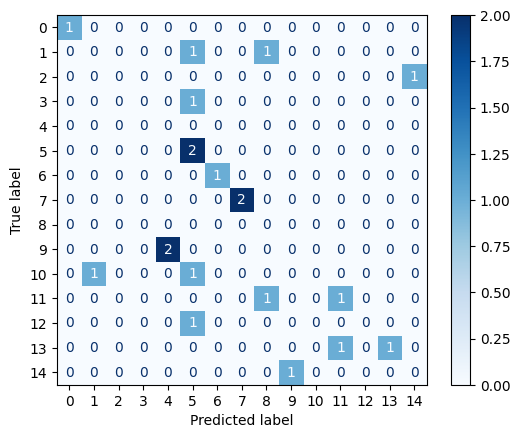

In [62]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues', values_format='d')  # 'd' for integers